# Semantic-Class ROI Attention Analysis

Notebook per analizzare le attenzioni del modello sui **72 campioni test unici** (`average_test_repeats=True`) e confrontare:

- attenzione iniziale del `TokenMapper` (`query -> ROI`)
- attenzione del backbone Stable Audio composta con il mapper (`latent -> brain token -> ROI`)

L'obiettivo e' capire se una **classe semantica** come `speech` mostra una firma ROI gia' nel mapper e se questa firma cambia nel backbone.

In [ ]:
# Se serve:
# !pip install diffusers transformers accelerate torchaudio seaborn pandas matplotlib --quiet

In [1]:
import os
import re
import math
import copy
import pickle
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from diffusers import StableAudioPipeline
from diffusers.models.embeddings import apply_rotary_emb
from diffusers.models.attention_processor import StableAudioAttnProcessor2_0
from diffusers.pipelines.stable_audio.pipeline_stable_audio import get_1d_rotary_pos_embed

from dataset import build_datasets, ROI_LIST
from model import AudioNeuroAdapter, StableAudioIPAttnProcessor2_0

sns.set_context('talk')
sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [74]:
# Configurazione
DATA_PATH = '/srv/nfs-data/sisko/matteoc/maas_2023/pooled_data.pkl'
WAV_DIR = '/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav'
SOUND_NAMES_PATH = '/home/matteoc/brainSounds/maas_data/SoundNames.npy'
CKPT_PATH = '/srv/nfs-data/sisko/matteoc/maas_2023/checkpoints/epoch_60.pt'

SPLIT = 'test'
AVERAGE_TEST_REPEATS = True
BATCH_SIZE = 4
NUM_WORKERS = 2
MAX_BATCHES = None

# Timesteps di probe nel backbone. Servono per vedere se il pattern cambia lungo il denoising.
PROBE_TIMESTEP_INDICES = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 999]

# Classe semantica da mettere in evidenza nei plot principali.
FOCUS_CLASS = 'nature'

SAVE_RESULTS = False
RESULTS_DIR = './attention_analysis_outputs_semantic'
os.makedirs(RESULTS_DIR, exist_ok=True)

In [75]:
def parse_semantic_class(sound_name: str) -> str:
    m = re.match(r'stim\d+_cat\d+_([a-zA-Z]+)_exemp\d+', str(sound_name))
    if m is None:
        raise ValueError(f'Impossibile estrarre la classe semantica da: {sound_name}')
    return m.group(1).lower()


def build_sound_metadata(sound_names: np.ndarray) -> pd.DataFrame:
    rows = []
    for idx, name in enumerate(sound_names):
        rows.append({
            'sound_idx': idx,
            'sound_name': str(name),
            'semantic_class': parse_semantic_class(str(name)),
        })
    return pd.DataFrame(rows)


def encode_audio_to_latents(vae, audio: torch.Tensor, device: torch.device) -> torch.Tensor:
    audio_in = audio.unsqueeze(1).to(device)
    audio_in = audio_in.expand(-1, 2, -1)
    with torch.no_grad():
        latents = vae.encode(audio_in).latent_dist.sample()
        scaling_factor = getattr(vae.config, 'scaling_factor', 1.0)
        latents = latents * scaling_factor
    return latents


def interpolation_matrix(in_len: int, out_len: int, device: torch.device) -> torch.Tensor:
    if in_len == out_len:
        return torch.eye(in_len, device=device)
    basis = torch.eye(in_len, device=device).unsqueeze(0)
    resized = F.interpolate(
        basis.transpose(1, 2),
        size=out_len,
        mode='linear',
        align_corners=False,
    ).transpose(1, 2)
    return resized.squeeze(0)


def get_brain_token_start_end(model: AudioNeuroAdapter, total_encoder_tokens: int):
    n_brain = model.audio_proj.out_len
    if model.conditioning_mode in {'brain_only', 'empty_prompt_plus_brain'}:
        return 0, n_brain
    if model.conditioning_mode == 'empty_prompt_ip_adapter':
        return None, None
    raise ValueError(f'conditioning_mode non supportata: {model.conditioning_mode}')


def load_model_and_data():
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model_config = ckpt.get('model_config', {})

    stable_audio_id = model_config.get('stable_audio_id', 'stabilityai/stable-audio-open-1.0')
    num_decoder_queries = model_config.get('num_decoder_queries', 16)
    target_duration_s = model_config.get('target_duration_s', 1.0)
    target_sr = model_config.get('target_sr', 44100)
    conditioning_mode = model_config.get('conditioning_mode', 'brain_only')
    train_backbone_cross_attention = model_config.get('train_backbone_cross_attention', False)
    train_cross_attention_proj = model_config.get('train_cross_attention_proj', False)
    cv = model_config.get('cv', 'CV2')

    pipe = StableAudioPipeline.from_pretrained(stable_audio_id, torch_dtype=torch.float32).to(device)

    model = AudioNeuroAdapter(
        pipe=pipe,
        num_rois=len(ROI_LIST),
        max_voxels=1024,
        num_decoder_queries=num_decoder_queries,
        target_duration_s=target_duration_s,
        conditioning_mode=conditioning_mode,
        train_backbone_cross_attention=train_backbone_cross_attention,
        train_cross_attention_proj=train_cross_attention_proj,
    ).to(device)

    model.guidance_generator.load_state_dict(ckpt['guidance_generator'])
    model.audio_proj.load_state_dict(ckpt['audio_proj'])
    if ckpt.get('ip_adapter_scale') is not None:
        model.ip_adapter_scale.data.copy_(ckpt['ip_adapter_scale'].to(device=device, dtype=model.ip_adapter_scale.dtype))
    if ckpt.get('brain_prompt_scale') is not None:
        model.brain_prompt_scale.data.copy_(ckpt['brain_prompt_scale'].to(device=device, dtype=model.brain_prompt_scale.dtype))
    if model.ip_adapter_modules is not None and ckpt.get('ip_adapter_modules') is not None:
        model.ip_adapter_modules.load_state_dict(ckpt['ip_adapter_modules'])
    if train_backbone_cross_attention and ckpt.get('trainable_backbone') is not None:
        model.pipe.transformer.load_state_dict(ckpt['trainable_backbone'])
    if ckpt.get('_brain_norm_mean') is not None:
        model._brain_norm_mean = ckpt['_brain_norm_mean'].to(device)
        model._brain_norm_std = ckpt['_brain_norm_std'].to(device)
    model.eval()

    with open(DATA_PATH, 'rb') as f:
        pooled_data = pickle.load(f)
    sound_names = np.load(SOUND_NAMES_PATH, allow_pickle=True)
    sound_meta = build_sound_metadata(sound_names)

    saved_normalizer = model.get_brain_normalizer()
    train_ds, test_ds = build_datasets(
        pooled_data=pooled_data,
        cv=cv,
        wav_dir=WAV_DIR,
        sound_names=sound_names,
        target_sr=target_sr,
        target_len_s=target_duration_s,
        average_test_repeats=AVERAGE_TEST_REPEATS,
        brain_normalizer_override=saved_normalizer,
    )

    dataset = test_ds if SPLIT == 'test' else train_ds
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return ckpt, model, loader, sound_meta


ckpt, model, loader, sound_meta = load_model_and_data()
print('conditioning_mode:', model.conditioning_mode)
print('Unique test sounds:', len(loader.dataset))
display(sound_meta['semantic_class'].value_counts().sort_index().rename('n_sounds').to_frame())

/tmp/ipykernel_1102946/2249361575.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Train: 1080 campioni | Test: 72 campioni
  brain_data shape: 6 ROI × 1024 voxels
  audio_target:     44100 samples @ 44100Hz (1.0s)
conditioning_mode: empty_prompt_ip_adapter
Unique test sounds: 72


,n_sounds
semantic_class,
animal,48
music,48
nature,48
speech,48
tools,48
voice,48


In [76]:
class MapperAttentionRecorder:
    def __init__(self, token_mapper):
        self.token_mapper = token_mapper
        self.handles = []
        self.records = []

    def _hook(self, module, inputs, output):
        if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
            self.records.append(output[1].detach().cpu())

    def __enter__(self):
        for layer in self.token_mapper.transformer.decoder.layers:
            self.handles.append(layer.multihead_attn.register_forward_hook(self._hook))
        return self

    def __exit__(self, exc_type, exc, tb):
        for h in self.handles:
            h.remove()
        self.handles = []

    def consume(self):
        if not self.records:
            return None
        stacked = torch.stack(self.records, dim=0)
        self.records = []
        return stacked


class AttentionStore:
    def __init__(self):
        self.cross = defaultdict(list)
        self.ip = defaultdict(list)

    def clear(self):
        self.cross.clear()
        self.ip.clear()


def _repeat_kv_to_all_heads(tensor: torch.Tensor, attn_heads: int) -> torch.Tensor:
    kv_heads = tensor.shape[1]
    if kv_heads == attn_heads:
        return tensor
    heads_per_kv_head = attn_heads // kv_heads
    return torch.repeat_interleave(tensor, heads_per_kv_head, dim=1, output_size=kv_heads * heads_per_kv_head)


def _attention_probs(query, key, attn_mask=None):
    scale = 1.0 / math.sqrt(query.shape[-1])
    scores = torch.matmul(query, key.transpose(-2, -1)) * scale
    if attn_mask is not None:
        scores = scores + attn_mask
    probs = torch.softmax(scores.float(), dim=-1).to(query.dtype)
    return probs


class RecordingStableAudioAttnProcessor2_0(nn.Module):
    def __init__(self, store: AttentionStore, name: str):
        super().__init__()
        self.store = store
        self.name = name

    def __call__(self, attn, hidden_states, encoder_hidden_states=None, attention_mask=None, rotary_emb=None):
        residual = hidden_states
        input_ndim = hidden_states.ndim

        if input_ndim == 4:
            batch_size, channel, height, width = hidden_states.shape
            hidden_states = hidden_states.view(batch_size, channel, height * width).transpose(1, 2)
        else:
            batch_size = hidden_states.shape[0]

        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
        elif attn.norm_cross:
            encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)

        sequence_length = encoder_hidden_states.shape[1]
        if attention_mask is not None:
            attention_mask = attn.prepare_attention_mask(attention_mask, sequence_length, batch_size)
            attention_mask = attention_mask.view(batch_size, attn.heads, -1, attention_mask.shape[-1])

        query = attn.to_q(hidden_states)
        key = attn.to_k(encoder_hidden_states)
        value = attn.to_v(encoder_hidden_states)

        head_dim = query.shape[-1] // attn.heads
        kv_heads = key.shape[-1] // head_dim

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)

        key = _repeat_kv_to_all_heads(key, attn.heads)
        value = _repeat_kv_to_all_heads(value, attn.heads)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)

        if rotary_emb is not None:
            query_dtype = query.dtype
            key_dtype = key.dtype
            query = query.to(torch.float32)
            key = key.to(torch.float32)
            rot_dim = rotary_emb[0].shape[-1]
            query_to_rotate, query_unrotated = query[..., :rot_dim], query[..., rot_dim:]
            query_rotated = apply_rotary_emb(query_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
            query = torch.cat((query_rotated, query_unrotated), dim=-1)
            if not attn.is_cross_attention:
                key_to_rotate, key_unrotated = key[..., :rot_dim], key[..., rot_dim:]
                key_rotated = apply_rotary_emb(key_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
                key = torch.cat((key_rotated, key_unrotated), dim=-1)
            query = query.to(query_dtype)
            key = key.to(key_dtype)

        probs = _attention_probs(query, key, attention_mask)
        if attn.is_cross_attention:
            self.store.cross[self.name].append(probs.detach().cpu())

        hidden_states = torch.matmul(probs, value)
        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
        hidden_states = hidden_states.to(query.dtype)
        hidden_states = attn.to_out[0](hidden_states)
        hidden_states = attn.to_out[1](hidden_states)

        if input_ndim == 4:
            hidden_states = hidden_states.transpose(-1, -2).reshape(batch_size, channel, height, width)
        if attn.residual_connection:
            hidden_states = hidden_states + residual
        hidden_states = hidden_states / attn.rescale_output_factor
        return hidden_states


class RecordingStableAudioIPAttnProcessor2_0(nn.Module):
    def __init__(self, base_processor: StableAudioIPAttnProcessor2_0, store: AttentionStore, name: str):
        super().__init__()
        self.hidden_size = base_processor.hidden_size
        self.cross_attention_dim = base_processor.cross_attention_dim
        self.num_tokens = base_processor.num_tokens
        self.scale = base_processor.scale
        self.to_k_ip = copy.deepcopy(base_processor.to_k_ip)
        self.to_v_ip = copy.deepcopy(base_processor.to_v_ip)
        self.store = store
        self.name = name

    def __call__(self, attn, hidden_states, encoder_hidden_states=None, attention_mask=None, rotary_emb=None):
        residual = hidden_states
        input_ndim = hidden_states.ndim

        if input_ndim == 4:
            batch_size, channel, height, width = hidden_states.shape
            hidden_states = hidden_states.view(batch_size, channel, height * width).transpose(1, 2)
        else:
            batch_size = hidden_states.shape[0]

        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
            ip_hidden_states = None
        else:
            if encoder_hidden_states.shape[1] < self.num_tokens:
                raise ValueError(f'Attesi almeno {self.num_tokens} token IP, ottenuti {encoder_hidden_states.shape[1]}.')
            split_idx = encoder_hidden_states.shape[1] - self.num_tokens
            encoder_hidden_states, ip_hidden_states = encoder_hidden_states[:, :split_idx, :], encoder_hidden_states[:, split_idx:, :]
            if attn.norm_cross:
                encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)

        sequence_length = encoder_hidden_states.shape[1]
        if attention_mask is not None:
            attention_mask = attn.prepare_attention_mask(attention_mask, sequence_length, batch_size)
            attention_mask = attention_mask.view(batch_size, attn.heads, -1, attention_mask.shape[-1])

        query = attn.to_q(hidden_states)
        key = attn.to_k(encoder_hidden_states)
        value = attn.to_v(encoder_hidden_states)

        head_dim = query.shape[-1] // attn.heads
        kv_heads = key.shape[-1] // head_dim

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)

        key = _repeat_kv_to_all_heads(key, attn.heads)
        value = _repeat_kv_to_all_heads(value, attn.heads)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)

        if rotary_emb is not None:
            query_dtype = query.dtype
            key_dtype = key.dtype
            query = query.to(torch.float32)
            key = key.to(torch.float32)
            rot_dim = rotary_emb[0].shape[-1]
            query_to_rotate, query_unrotated = query[..., :rot_dim], query[..., rot_dim:]
            query_rotated = apply_rotary_emb(query_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
            query = torch.cat((query_rotated, query_unrotated), dim=-1)
            if not attn.is_cross_attention:
                key_to_rotate, key_unrotated = key[..., :rot_dim], key[..., rot_dim:]
                key_rotated = apply_rotary_emb(key_to_rotate, rotary_emb, use_real=True, use_real_unbind_dim=-2)
                key = torch.cat((key_rotated, key_unrotated), dim=-1)
            query = query.to(query_dtype)
            key = key.to(key_dtype)

        probs = _attention_probs(query, key, attention_mask)
        if attn.is_cross_attention:
            self.store.cross[self.name].append(probs.detach().cpu())
        hidden_states_main = torch.matmul(probs, value)

        if ip_hidden_states is not None:
            ip_key = self.to_k_ip(ip_hidden_states)
            ip_value = self.to_v_ip(ip_hidden_states)
            ip_key = ip_key.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
            ip_value = ip_value.view(batch_size, -1, kv_heads, head_dim).transpose(1, 2)
            ip_key = _repeat_kv_to_all_heads(ip_key, attn.heads)
            ip_value = _repeat_kv_to_all_heads(ip_value, attn.heads)
            if attn.norm_k is not None:
                ip_key = attn.norm_k(ip_key)
            ip_probs = _attention_probs(query, ip_key, None)
            self.store.ip[self.name].append(ip_probs.detach().cpu())
            hidden_states_ip = torch.matmul(ip_probs, ip_value)
            hidden_states = hidden_states_main + self.scale * hidden_states_ip
        else:
            hidden_states = hidden_states_main

        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
        hidden_states = hidden_states.to(query.dtype)
        hidden_states = attn.to_out[0](hidden_states)
        hidden_states = attn.to_out[1](hidden_states)

        if input_ndim == 4:
            hidden_states = hidden_states.transpose(-1, -2).reshape(batch_size, channel, height, width)
        if attn.residual_connection:
            hidden_states = hidden_states + residual
        hidden_states = hidden_states / attn.rescale_output_factor
        return hidden_states


def swap_in_recording_processors(model: AudioNeuroAdapter, store: AttentionStore):
    transformer = model.pipe.transformer
    original = copy.deepcopy(transformer.attn_processors)
    wrapped = {}
    for name, proc in transformer.attn_processors.items():
        if '.attn1.' in name:
            wrapped[name] = proc
        elif isinstance(proc, StableAudioIPAttnProcessor2_0):
            wrapped[name] = RecordingStableAudioIPAttnProcessor2_0(proc, store, name)
        else:
            wrapped[name] = RecordingStableAudioAttnProcessor2_0(store, name)
    transformer.set_attn_processor(wrapped)
    return original


def restore_processors(model: AudioNeuroAdapter, original_processors):
    model.pipe.transformer.set_attn_processor(original_processors)

In [77]:
@torch.no_grad()
def analyze_semantic_attention(model: AudioNeuroAdapter, loader: DataLoader, sound_meta: pd.DataFrame, max_batches=None):
    scheduler = model.pipe.scheduler
    scheduler.set_timesteps(1000, device=device)
    available_timesteps = scheduler.timesteps.detach().cpu()
    timestep_indices = [idx for idx in PROBE_TIMESTEP_INDICES if idx < len(available_timesteps)]
    probe_timesteps = available_timesteps[timestep_indices]

    n_queries = model.guidance_generator.token_mapper.decoder_queries.num_embeddings
    n_brain_tokens = model.audio_proj.out_len
    query_to_projected = interpolation_matrix(n_queries, n_brain_tokens, device).detach().cpu()

    rows_mapper_roi = []
    rows_mapper_query_roi = []
    rows_backbone_roi = []
    rows_backbone_timestep_roi = []

    sound_meta_map = sound_meta.set_index('sound_idx')
    attn_store = AttentionStore()
    original_processors = swap_in_recording_processors(model, attn_store)

    try:
        for batch_idx, batch in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            brain = batch['brain_data'].to(device)
            audio = batch['audio_target'].to(device)
            sound_idx = batch['sound_idx'].cpu().numpy()
            B = brain.shape[0]

            with MapperAttentionRecorder(model.guidance_generator.token_mapper) as mapper_rec:
                condition_tokens, _ = model.guidance_generator(brain)
            mapper_attn = mapper_rec.consume()
            if mapper_attn is None:
                raise RuntimeError('Non sono riuscito a catturare l\'attenzione del TokenMapper.')

            mapper_attn = mapper_attn.mean(dim=0)
            if mapper_attn.ndim == 4:
                mapper_attn = mapper_attn.mean(dim=1)

            mapper_projected = torch.einsum('tq,bqr->btr', query_to_projected, mapper_attn.cpu())
            encoder_hidden_states, global_hidden_states = model.build_conditioning(brain, device=device)
            latents = encode_audio_to_latents(model.pipe.vae, audio, device=device)

            for i in range(B):
                meta = sound_meta_map.loc[int(sound_idx[i])]
                sample_mapper = mapper_attn[i]
                sample_mapper_roi = sample_mapper.mean(dim=0).numpy()

                row = {
                    'sound_idx': int(sound_idx[i]),
                    'sound_name': meta['sound_name'],
                    'semantic_class': meta['semantic_class'],
                }
                for roi_name, value in zip(ROI_LIST, sample_mapper_roi):
                    row[roi_name] = float(value)
                rows_mapper_roi.append(row)

                for q in range(sample_mapper.shape[0]):
                    row_q = {
                        'sound_idx': int(sound_idx[i]),
                        'sound_name': meta['sound_name'],
                        'semantic_class': meta['semantic_class'],
                        'query_idx': q,
                    }
                    for roi_name, value in zip(ROI_LIST, sample_mapper[q].numpy()):
                        row_q[roi_name] = float(value)
                    rows_mapper_query_roi.append(row_q)

            for t_idx, t in zip(timestep_indices, probe_timesteps):
                attn_store.clear()
                timestep = t.to(device).unsqueeze(0).expand(B)
                noise = torch.randn_like(latents)
                noisy_latents = scheduler.add_noise(latents, noise, timestep)
                latent_input = scheduler.scale_model_input(noisy_latents, t.to(device))

                rotary_embedding = get_1d_rotary_pos_embed(
                    model.pipe.rotary_embed_dim,
                    latent_input.shape[2] + global_hidden_states.shape[1],
                    use_real=True,
                    repeat_interleave_real=False,
                )
                rotary_embedding = tuple(r.to(device) for r in rotary_embedding)

                _ = model.pipe.transformer(
                    hidden_states=latent_input,
                    timestep=timestep,
                    encoder_hidden_states=encoder_hidden_states,
                    global_hidden_states=global_hidden_states,
                    rotary_embedding=rotary_embedding,
                    return_dict=False,
                )[0]

                bank = attn_store.ip if model.conditioning_mode == 'empty_prompt_ip_adapter' else attn_store.cross
                if not bank:
                    continue

                layer_tensors = []
                for _, tensors in sorted(bank.items()):
                    if not tensors:
                        continue
                    layer_probs = torch.stack(tensors, dim=0).mean(dim=0)
                    if model.conditioning_mode != 'empty_prompt_ip_adapter':
                        start_end = get_brain_token_start_end(model, layer_probs.shape[-1])
                        if start_end[0] is None:
                            continue
                        start, end = start_end
                        layer_probs = layer_probs[..., start:end]
                    layer_tensors.append(layer_probs)

                if not layer_tensors:
                    continue

                backbone_attn = torch.stack(layer_tensors, dim=0).mean(dim=0)
                backbone_attn = backbone_attn.mean(dim=1)
                transported = torch.einsum('blt,btr->blr', backbone_attn.cpu(), mapper_projected)

                for i in range(B):
                    meta = sound_meta_map.loc[int(sound_idx[i])]
                    sample_transport = transported[i].mean(dim=0).numpy()
                    row = {
                        'sound_idx': int(sound_idx[i]),
                        'sound_name': meta['sound_name'],
                        'semantic_class': meta['semantic_class'],
                        'timestep_index': int(t_idx),
                        'timestep_value': int(t.item()),
                    }
                    for roi_name, value in zip(ROI_LIST, sample_transport):
                        row[roi_name] = float(value)
                    rows_backbone_timestep_roi.append(row)

            if (batch_idx + 1) % 5 == 0:
                print(f'Processed {batch_idx + 1} batches / {len(loader)}')

    finally:
        restore_processors(model, original_processors)

    mapper_roi_df = pd.DataFrame(rows_mapper_roi)
    mapper_query_roi_df = pd.DataFrame(rows_mapper_query_roi)
    backbone_timestep_roi_df = pd.DataFrame(rows_backbone_timestep_roi)
    backbone_roi_df = backbone_timestep_roi_df.groupby(['sound_idx', 'sound_name', 'semantic_class'], as_index=False)[ROI_LIST].mean()

    class_mapper_roi = mapper_roi_df.groupby('semantic_class', as_index=False)[ROI_LIST].mean()
    class_backbone_roi = backbone_roi_df.groupby('semantic_class', as_index=False)[ROI_LIST].mean()
    class_backbone_timestep_roi = backbone_timestep_roi_df.groupby(['semantic_class', 'timestep_index', 'timestep_value'], as_index=False)[ROI_LIST].mean()
    class_mapper_query_roi = mapper_query_roi_df.groupby(['semantic_class', 'query_idx'], as_index=False)[ROI_LIST].mean()

    return {
        'mapper_roi_df': mapper_roi_df,
        'mapper_query_roi_df': mapper_query_roi_df,
        'backbone_roi_df': backbone_roi_df,
        'backbone_timestep_roi_df': backbone_timestep_roi_df,
        'class_mapper_roi': class_mapper_roi,
        'class_backbone_roi': class_backbone_roi,
        'class_backbone_timestep_roi': class_backbone_timestep_roi,
        'class_mapper_query_roi': class_mapper_query_roi,
    }


results = analyze_semantic_attention(model, loader, sound_meta, max_batches=MAX_BATCHES)
print('Analisi completata.')
print('72 test unici attesi, trovati:', len(results['mapper_roi_df']))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Processed 5 batches / 18
Processed 10 batches / 18
Processed 15 batches / 18


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Analisi completata.
72 test unici attesi, trovati: 72


In [78]:
def to_long_roi(df: pd.DataFrame, id_vars):
    return df.melt(id_vars=id_vars, value_vars=ROI_LIST, var_name='ROI', value_name='score')


class_mapper_long = to_long_roi(results['class_mapper_roi'], ['semantic_class'])
class_backbone_long = to_long_roi(results['class_backbone_roi'], ['semantic_class'])

class_compare = class_mapper_long.merge(
    class_backbone_long,
    on=['semantic_class', 'ROI'],
    suffixes=('_mapper', '_backbone')
)
class_compare['delta_backbone_minus_mapper'] = class_compare['score_backbone'] - class_compare['score_mapper']

display(class_compare.sort_values(['semantic_class', 'score_backbone'], ascending=[True, False]).head(30))

,semantic_class,ROI,score_mapper,score_backbone,delta_backbone_minus_mapper
30,animal,aSTG2hem,0.218579,0.219600,0.001022
12,animal,PP2hem,0.216633,0.202738,-0.013896
0,animal,HG2hem,0.205345,0.174798,-0.030547
18,animal,mSTG2hem,0.121887,0.147088,0.025201
6,animal,PT2hem,0.154237,0.132471,-0.021766
24,animal,pSTG2hem,0.083319,0.123305,0.039986
31,music,aSTG2hem,0.218986,0.217983,-0.001003
13,music,PP2hem,0.215096,0.206698,-0.008398
1,music,HG2hem,0.209161,0.189734,-0.019428
7,music,PT2hem,0.152480,0.138810,-0.013671


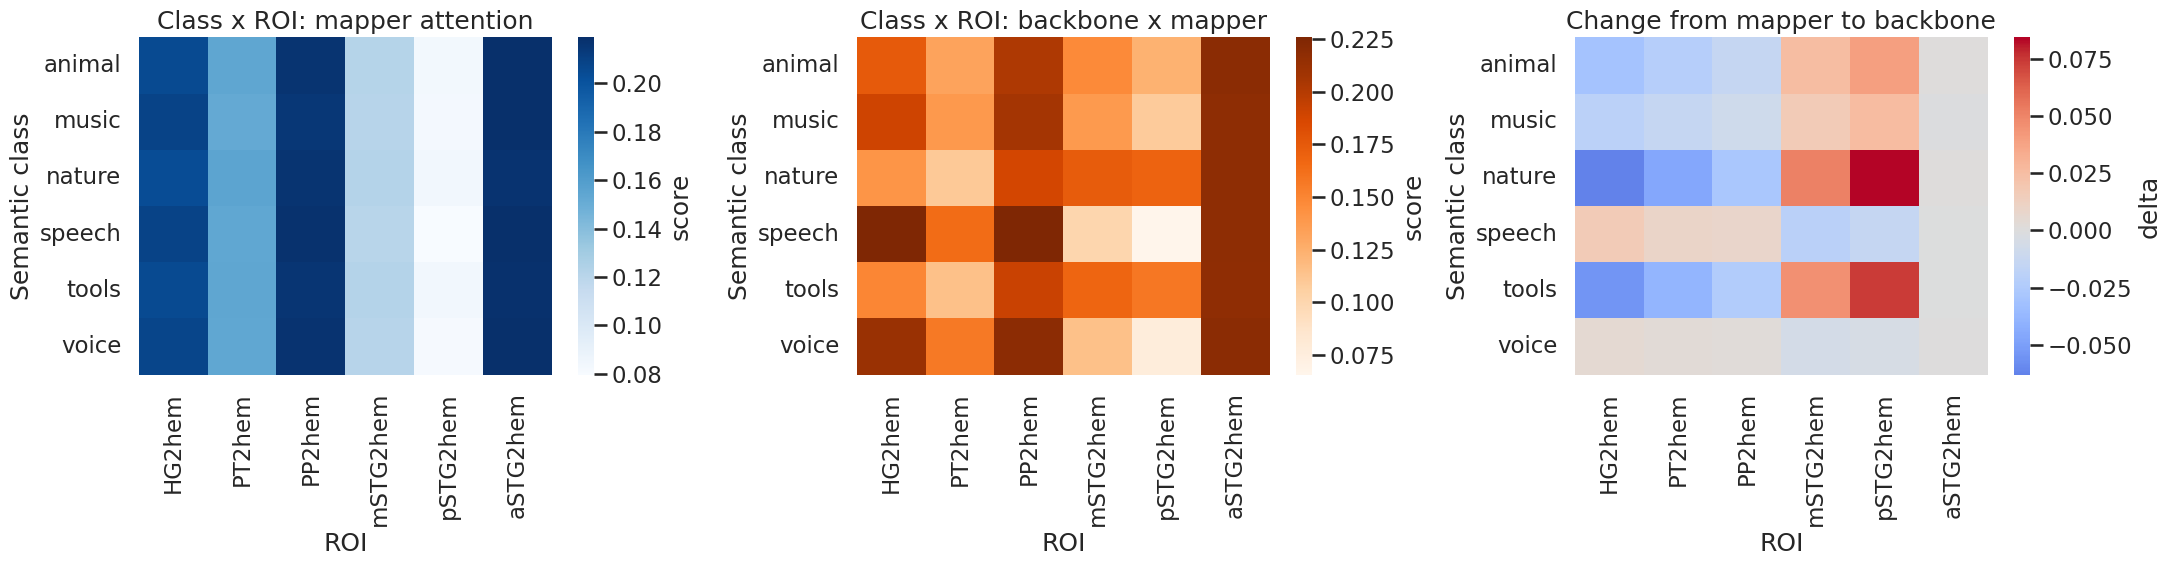

In [79]:
mapper_heat = results['class_mapper_roi'].set_index('semantic_class')[ROI_LIST]
backbone_heat = results['class_backbone_roi'].set_index('semantic_class')[ROI_LIST]
delta_heat = backbone_heat - mapper_heat

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.heatmap(mapper_heat, cmap='Blues', ax=axes[0], cbar_kws={'label': 'score'})
axes[0].set_title('Class x ROI: mapper attention')
axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Semantic class')

sns.heatmap(backbone_heat, cmap='Oranges', ax=axes[1], cbar_kws={'label': 'score'})
axes[1].set_title('Class x ROI: backbone x mapper')
axes[1].set_xlabel('ROI')
axes[1].set_ylabel('Semantic class')

sns.heatmap(delta_heat, cmap='coolwarm', center=0.0, ax=axes[2], cbar_kws={'label': 'delta'})
axes[2].set_title('Change from mapper to backbone')
axes[2].set_xlabel('ROI')
axes[2].set_ylabel('Semantic class')
plt.tight_layout()
plt.show()

,ROI,mapper,backbone_x_mapper,delta
5,aSTG2hem,0.216917,0.218363,0.001446
2,PP2hem,0.216538,0.188357,-0.028181
3,mSTG2hem,0.122226,0.173532,0.051306
4,pSTG2hem,0.084518,0.169123,0.084605
0,HG2hem,0.204035,0.140883,-0.063152
1,PT2hem,0.155766,0.109742,-0.046024


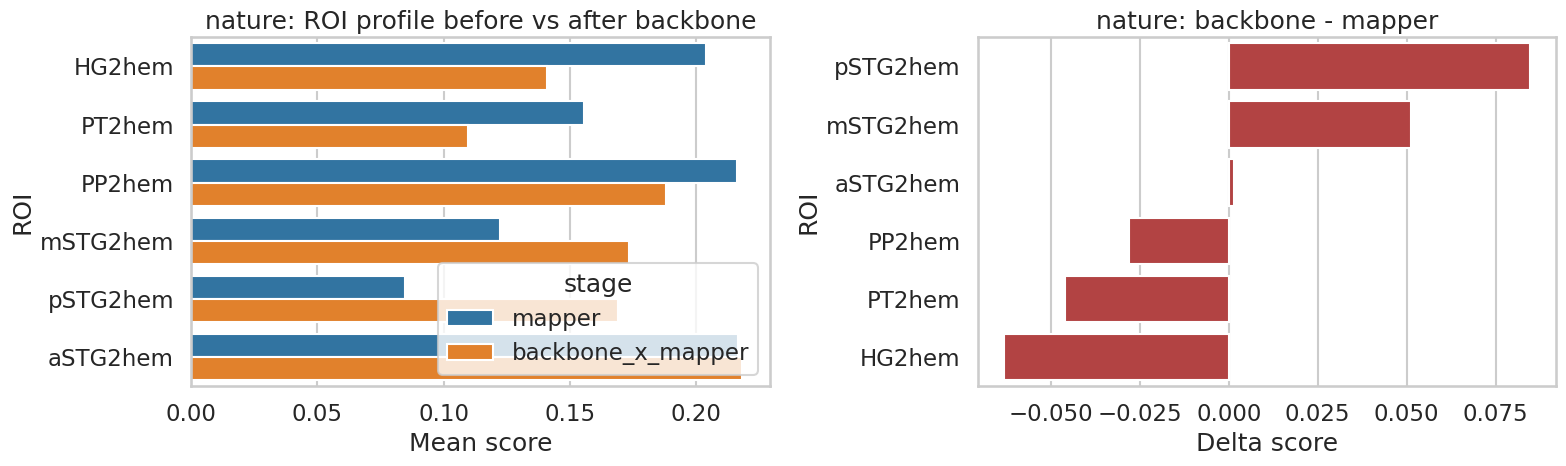

In [80]:
focus_mapper = results['class_mapper_roi'].query('semantic_class == @FOCUS_CLASS')
focus_backbone = results['class_backbone_roi'].query('semantic_class == @FOCUS_CLASS')

if len(focus_mapper) == 0:
    raise ValueError(f'Classe {FOCUS_CLASS} non trovata.')

focus_compare = pd.DataFrame({
    'ROI': ROI_LIST,
    'mapper': focus_mapper[ROI_LIST].iloc[0].values,
    'backbone_x_mapper': focus_backbone[ROI_LIST].iloc[0].values,
})
focus_compare['delta'] = focus_compare['backbone_x_mapper'] - focus_compare['mapper']
display(focus_compare.sort_values('backbone_x_mapper', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=focus_compare.melt(id_vars='ROI', value_vars=['mapper', 'backbone_x_mapper'], var_name='stage', value_name='score'), x='score', y='ROI', hue='stage', ax=axes[0])
axes[0].set_title(f'{FOCUS_CLASS}: ROI profile before vs after backbone')
axes[0].set_xlabel('Mean score')
axes[0].set_ylabel('ROI')

sns.barplot(data=focus_compare.sort_values('delta', ascending=False), x='delta', y='ROI', color='#c53030', ax=axes[1])
axes[1].set_title(f'{FOCUS_CLASS}: backbone - mapper')
axes[1].set_xlabel('Delta score')
axes[1].set_ylabel('ROI')
plt.tight_layout()
plt.show()

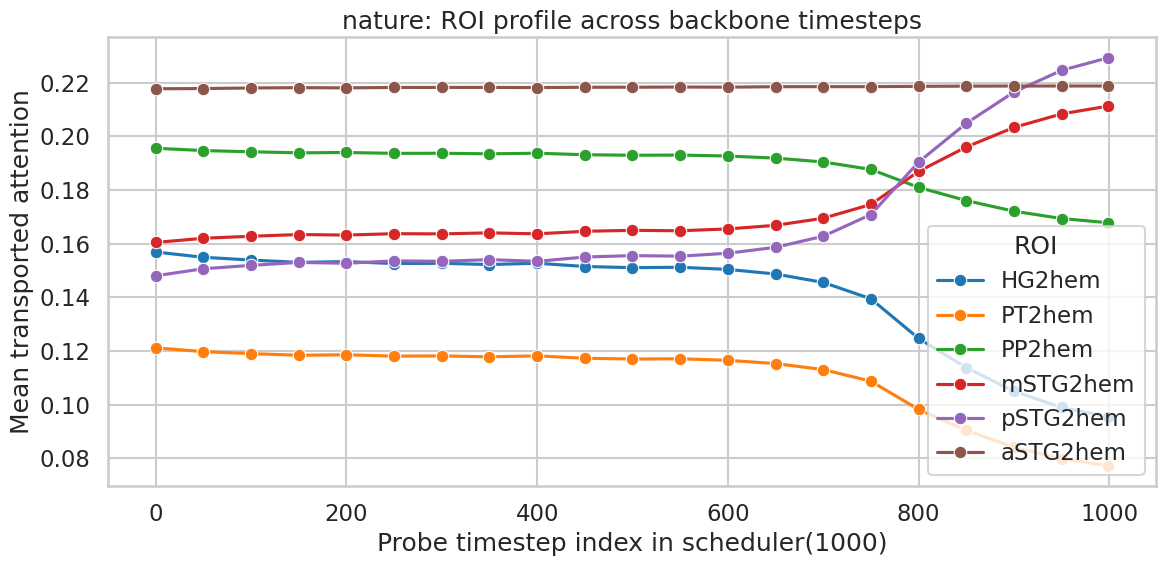

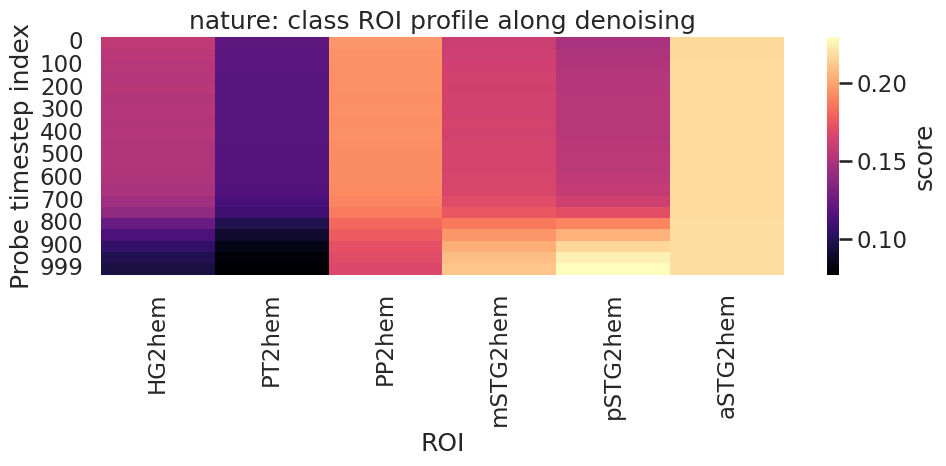

In [81]:
focus_time = results['class_backbone_timestep_roi'].query('semantic_class == @FOCUS_CLASS').copy()
focus_time_long = to_long_roi(focus_time, ['semantic_class', 'timestep_index', 'timestep_value'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=focus_time_long, x='timestep_index', y='score', hue='ROI', marker='o')
plt.title(f'{FOCUS_CLASS}: ROI profile across backbone timesteps')
plt.xlabel('Probe timestep index in scheduler(1000)')
plt.ylabel('Mean transported attention')
plt.tight_layout()
plt.show()

pivot_focus_time = focus_time.set_index('timestep_index')[ROI_LIST]
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_focus_time, cmap='magma', cbar_kws={'label': 'score'})
plt.title(f'{FOCUS_CLASS}: class ROI profile along denoising')
plt.xlabel('ROI')
plt.ylabel('Probe timestep index')
plt.tight_layout()
plt.show()

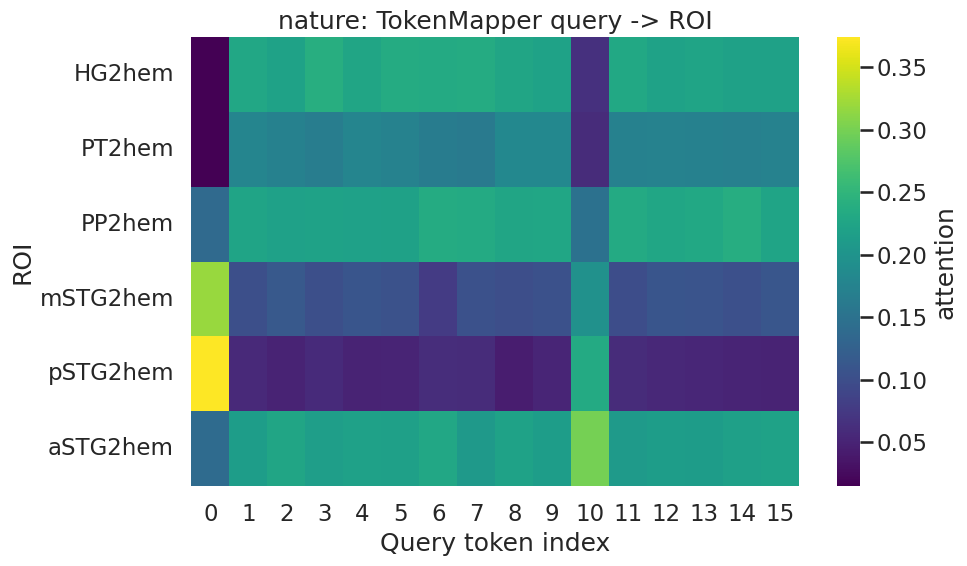

In [82]:
focus_query = results['class_mapper_query_roi'].query('semantic_class == @FOCUS_CLASS').copy()
focus_query_heat = focus_query.set_index('query_idx')[ROI_LIST]

plt.figure(figsize=(10, 6))
sns.heatmap(focus_query_heat.T, cmap='viridis', cbar_kws={'label': 'attention'})
plt.title(f'{FOCUS_CLASS}: TokenMapper query -> ROI')
plt.xlabel('Query token index')
plt.ylabel('ROI')
plt.tight_layout()
plt.show()

## Come leggere i risultati

- Il notebook lavora sui **72 item test unici**, quindi ogni suono contribuisce una sola volta all'analisi di classe.
- `class_mapper_roi` dice quali ROI sono privilegiate dal mapper per ogni classe semantica.
- `class_backbone_roi` dice quali ROI restano importanti dopo aver composto l'attenzione del backbone con quella del mapper.
- `delta = backbone - mapper` mostra dove il backbone enfatizza o de-enfatizza una ROI rispetto all'attenzione iniziale.
- `class_backbone_timestep_roi` serve per vedere se il profilo ROI cambia lungo il denoising.

### Claim prudente ma utile

Per una classe come `speech`, puoi dire qualcosa del tipo:

- "Nel mapper, `speech` mostra una preferenza iniziale per queste ROI..."
- "Nel backbone, questa preferenza si concentra / si redistribuisce verso queste ROI..."
- "Quindi la firma neurale iniziale della classe viene mantenuta oppure trasformata durante la generazione."

### Limite importante

Attenzione alta non significa causalita'. Se vuoi un risultato piu' convincente sul cervello, il passo naturale dopo questo notebook e' un'analisi di **ROI ablation per classe semantica**.